# MetFoundation: Metabolic Subtype Prediction Demo

This notebook demonstrates how to predict metabolic subtypes using pre-extracted embeddings from the MetFoundation model.

## Overview
- Load pre-extracted embeddings from the MetFoundation model
- Load the trained metabolic subtype classifier
- Predict metabolic subtypes for samples
- Analyze and visualize the subtype distribution

## Reference subtype-disease patterns derived from the training set in the original paper of MetFoundation
![subtype_disease](./subtype_disease_coxph_heatmap_meta_subtypes.png)

## 1. Import Required Libraries

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import pickle
import joblib
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Add Src directory to path for importing custom modules
sys.path.append('./Src')

from utils import set_seeds

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.3.3


## 2. Configuration

Set up paths for loading embeddings, classifier model, and original data.

In [2]:
# Set random seed for reproducibility
set_seeds(3047)

# Configuration paths
embeddings_path = './Demo_output/val_embeddings.pkl' # obtained from 1_embedding_extraction.ipynb
classifier_path = './Defined_Tools/subtype_classifier.joblib' # trained using the training set defined in the original paper of MetFoundation
data_path = './Data/UKB_NMR/val.h5ad'

print(f"Embeddings path: {embeddings_path}")
print(f"Classifier path: {classifier_path}")
print(f"Data path: {data_path}")

# Verify all files exist
if not os.path.exists(embeddings_path):
    raise FileNotFoundError(f"Embeddings file not found: {embeddings_path}")
if not os.path.exists(classifier_path):
    raise FileNotFoundError(f"Classifier model not found: {classifier_path}")
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found: {data_path}")

print("\nAll required files found!")

Embeddings path: ./Demo_output/val_embeddings.pkl
Classifier path: ./Defined_Tools/subtype_classifier.joblib
Data path: ./Data/UKB_NMR/val.h5ad

All required files found!


## 3. Load Pre-extracted Embeddings

Load the embeddings that were extracted from the MetFoundation model.

In [3]:
# Load embeddings from pickle file
with open(embeddings_path, 'rb') as f:
    embedding_data = pickle.load(f)

# Extract embeddings and metadata
embeddings = embedding_data['embeddings']
sample_ids = embedding_data['sample_ids']

print(f"Embeddings loaded successfully!")
print(f"Number of samples: {embeddings.shape[0]}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Number of sample IDs: {len(sample_ids)}")

# Basic statistics
print(f"\nEmbedding statistics:")
print(f"Mean: {np.mean(embeddings):.4f}")
print(f"Std: {np.std(embeddings):.4f}")
print(f"Min: {np.min(embeddings):.4f}")
print(f"Max: {np.max(embeddings):.4f}")



Embeddings loaded successfully!
Number of samples: 4320
Embedding dimension: 512
Number of sample IDs: 4320

Embedding statistics:
Mean: -0.0004
Std: 0.6936
Min: -7.7427
Max: 4.7078


## 4. Load Metabolic Subtype Classifier

Load the pre-trained classifier model that predicts metabolic subtypes from embeddings.

In [4]:
np.__version__

'2.0.2'

In [5]:
# Load the subtype classifier with automatic package reinstallation if needed
## Binary incompatibility issues can cause joblib loading to fail
import subprocess
import sys
import os

print(f"Current NumPy version: {np.__version__}")

try:
    # Try loading the classifier
    print("Attempting to load classifier...")
    classifier = joblib.load(classifier_path)
    print(f"Classifier loaded successfully!")
    
except (ValueError, AttributeError, ImportError) as e:
    # If loading fails due to numpy compatibility issue
    error_msg = str(e)
    print(f"\nLoading failed with error: {error_msg}")
    
    # Detect NumPy compatibility issues
    is_numpy_issue = any(keyword in error_msg for keyword in [
        "dtype size changed", "binary incompatibility", "MT19937", "BitGenerator"
    ])
    
    if is_numpy_issue:
        print("\nDetected NumPy compatibility issue.")
        print("Automatically upgrading NumPy and reinstalling dependent packages...")
        print("=" * 60)
        
        # Get conda path from environment
        conda_exe = os.environ.get('CONDA_EXE', 'conda')
        
        # Step 1: Upgrade NumPy first
        print("\n[Step 1/2] Upgrading NumPy to version 2.0.2...")
        cmd = f'{conda_exe} install -y numpy=2.0.2'
        print(f"Running: {cmd}")
        
        result = subprocess.run(
            cmd,
            shell=True,
            capture_output=True,
            text=True,
            executable='/bin/bash'
        )
        
        if result.returncode == 0:
            print("✓ NumPy upgraded successfully")
        else:
            print(f"✗ NumPy upgrade failed")
            print(f"  stderr: {result.stderr}")
        
        # Step 2: Reinstall packages that depend on NumPy
        print("\n[Step 2/2] Reinstalling NumPy-dependent packages...")
        packages_to_reinstall = ['scikit-learn', 'pandas', 'scipy']
        
        for package in packages_to_reinstall:
            print(f"\nReinstalling {package}...")
            cmd = f'{conda_exe} install -y --force-reinstall {package}'
            print(f"Running: {cmd}")
            
            result = subprocess.run(
                cmd,
                shell=True,
                capture_output=True,
                text=True,
                executable='/bin/bash'
            )
            
            if result.returncode == 0:
                print(f"✓ {package} reinstalled successfully")
            else:
                print(f"✗ {package} reinstallation failed")
                print(f"  stderr: {result.stderr}")
        
        print("\n" + "="*60)
        print("All packages upgraded/reinstalled successfully!")
        print("IMPORTANT: Please restart the kernel and re-run all cells")
        print("to use the newly installed packages.")
        print("="*60)
        raise SystemExit("Please restart kernel to use updated packages")
        
    else:
        # Other type of error
        print("\nUnexpected error occurred.")
        print("Please check the error message and try manually debugging.")
        raise

# Display classifier information
print(f"\nClassifier type: {type(classifier).__name__}")

# Check if classifier has classes_ attribute (for classification models)
if hasattr(classifier, 'classes_'):
    print(f"Number of metabolic subtypes: {len(classifier.classes_)}")
    print(f"Subtype labels: {classifier.classes_}")
    
# Check if classifier has feature_importances_ (for tree-based models)
if hasattr(classifier, 'feature_importances_'):
    print(f"Model has feature importances available")
    
# Check if classifier has n_features_in_ attribute
if hasattr(classifier, 'n_features_in_'):
    print(f"Expected number of features: {classifier.n_features_in_}")

Current NumPy version: 2.0.2
Attempting to load classifier...
Classifier loaded successfully!

Classifier type: MLPClassifier
Number of metabolic subtypes: 13
Subtype labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Expected number of features: 512


## 5. Load Original Data

Load the original metabolomic data to access sample metadata.

In [6]:
# Load the AnnData object
adata = ad.read_h5ad(data_path)

print(f"Data loaded successfully!")
print(f"Number of samples: {adata.n_obs}")
print(f"Number of metabolites: {adata.n_vars}")

# Check available metadata
print(f"\nAvailable observation metadata columns:")
for col in adata.obs.columns:
    print(f"  - {col}")

print(f"\nAvailable data layers:")
for layer in adata.layers.keys():
    print(f"  - {layer}")

# Verify sample IDs match
print(f"\nSample ID verification:")
print(f"Sample IDs from embeddings match data: {all(sid in adata.obs_names for sid in sample_ids)}")

Data loaded successfully!
Number of samples: 4320
Number of metabolites: 107

Available observation metadata columns:
  - Age at assessment (estimated)
  - Sex
  - Body mass index (BMI)
  - UK Biobank assessment centre
  - Date of attending assessment centre
  - Death follow-up time
  - Death event
  - Death event time
  - UK Biobank assessment area
  - instance

Available data layers:
  - Z-score normalized

Sample ID verification:
Sample IDs from embeddings match data: True


## 6. Predict Metabolic Subtypes

Use the classifier to predict metabolic subtypes from the embeddings.

In [7]:
# Predict metabolic subtypes
print("Predicting metabolic subtypes...")
predicted_subtypes = classifier.predict(embeddings)

print(f"\nPrediction completed!")
print(f"Total predictions: {len(predicted_subtypes)}")
print(f"Unique subtypes predicted: {len(np.unique(predicted_subtypes))}")
print(f"Subtype values: {np.unique(predicted_subtypes)}")

# Get prediction probabilities if available
if hasattr(classifier, 'predict_proba'):
    prediction_probs = classifier.predict_proba(embeddings)
    print(f"\nPrediction probabilities shape: {prediction_probs.shape}")
    print(f"Average max probability: {np.max(prediction_probs, axis=1).mean():.4f}")
    print(f"Min max probability: {np.max(prediction_probs, axis=1).min():.4f}")
else:
    prediction_probs = None
    print("\nPrediction probabilities not available for this classifier type.")

Predicting metabolic subtypes...

Prediction completed!
Total predictions: 4320
Unique subtypes predicted: 13
Subtype values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]

Prediction probabilities shape: (4320, 13)
Average max probability: 0.9151
Min max probability: 0.3405


## 7. Analyze Subtype Distribution

Analyze the distribution of predicted metabolic subtypes.

In [8]:
# Count subtype distribution
subtype_counts = Counter(predicted_subtypes)
subtype_df = pd.DataFrame({
    'Subtype': list(subtype_counts.keys()),
    'Count': list(subtype_counts.values())
}).sort_values('Subtype')

# Calculate percentages
subtype_df['Percentage'] = (subtype_df['Count'] / len(predicted_subtypes) * 100).round(2)

print("Metabolic Subtype Distribution:")
print(subtype_df.to_string(index=False))

# Summary statistics
print(f"\nSummary:")
print(f"Total samples: {len(predicted_subtypes)}")
print(f"Number of unique subtypes: {len(subtype_counts)}")
print(f"Most common subtype: {subtype_df.iloc[subtype_df['Count'].argmax()]['Subtype']} ({subtype_df['Count'].max()} samples, {subtype_df['Percentage'].max():.2f}%)")
print(f"Least common subtype: {subtype_df.iloc[subtype_df['Count'].argmin()]['Subtype']} ({subtype_df['Count'].min()} samples, {subtype_df['Percentage'].min():.2f}%)")

Metabolic Subtype Distribution:
 Subtype  Count  Percentage
       0    761       17.62
       1    746       17.27
       2    778       18.01
       3    516       11.94
       4    566       13.10
       5    396        9.17
       6    426        9.86
       7     38        0.88
       8     30        0.69
       9     37        0.86
      10     11        0.25
      11     13        0.30
      12      2        0.05

Summary:
Total samples: 4320
Number of unique subtypes: 13
Most common subtype: 2.0 (778 samples, 18.01%)
Least common subtype: 12.0 (2 samples, 0.05%)


## 8. Visualize Subtype Distribution

Create visualizations to better understand the metabolic subtype distribution.

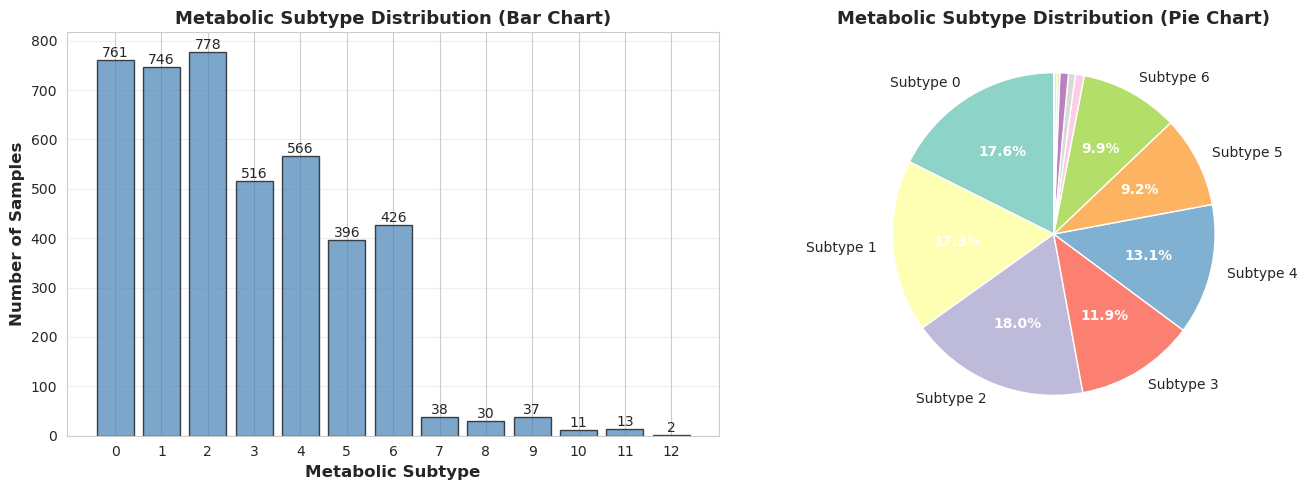


Visualization completed!


In [9]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart
ax1 = axes[0]
bars = ax1.bar(subtype_df['Subtype'].astype(str), subtype_df['Count'], 
               color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Metabolic Subtype', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Metabolic Subtype Distribution (Bar Chart)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

# Plot 2: Pie chart
ax2 = axes[1]
colors = sns.color_palette('Set3', len(subtype_df))

# Calculate percentages and create labels only for >= 5%
percentages = (subtype_df['Count'] / len(predicted_subtypes) * 100).values
labels = [f'Subtype {s}' if pct >= 5 else '' for s, pct in zip(subtype_df['Subtype'], percentages)]

# Function to only show percentage if >= 5%
def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''

wedges, texts, autotexts = ax2.pie(subtype_df['Count'], 
                                     labels=labels, 
                                     autopct=autopct_format,
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 10})
ax2.set_title('Metabolic Subtype Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

print("\nVisualization completed!")

## 8b. Define Meta-Subtype Grouping

Meta-subtypes represent a hierarchical grouping of fine-grained subtypes into broader metabolic categories.

In [10]:
meta_subtypes = {
    1: [8],
    2: [0, 5, 2, 3],
    3: [6, 9, 12, 7, 10],
    4: [4, 1, 11]
}

## 8c. Convert to Meta-Subtypes

Convert the fine-grained subtype predictions to meta-subtype categories.

In [11]:
# Convert subtypes to meta-subtypes
# Create a mapping from subtype to meta-subtype
subtype_to_meta = {}
for meta_subtype, subtypes in meta_subtypes.items():
    for subtype in subtypes:
        subtype_to_meta[subtype] = meta_subtype

print("Subtype to Meta-subtype mapping:")
for subtype in sorted(subtype_to_meta.keys()):
    print(f"  Subtype {subtype} -> Meta-subtype {subtype_to_meta[subtype]}")

# Convert predicted subtypes to meta-subtypes
predicted_meta_subtypes = np.array([subtype_to_meta[s] for s in predicted_subtypes])

print(f"\nMeta-subtype prediction completed!")
print(f"Total predictions: {len(predicted_meta_subtypes)}")
print(f"Unique meta-subtypes predicted: {len(np.unique(predicted_meta_subtypes))}")
print(f"Meta-subtype values: {np.unique(predicted_meta_subtypes)}")

# Count meta-subtype distribution
meta_subtype_counts = Counter(predicted_meta_subtypes)
meta_subtype_df = pd.DataFrame({
    'Meta_Subtype': list(meta_subtype_counts.keys()),
    'Count': list(meta_subtype_counts.values())
}).sort_values('Meta_Subtype')

# Calculate percentages
meta_subtype_df['Percentage'] = (meta_subtype_df['Count'] / len(predicted_meta_subtypes) * 100).round(2)

print("\nMetabolic Meta-Subtype Distribution:")
print(meta_subtype_df.to_string(index=False))

# Summary statistics
print(f"\nSummary:")
print(f"Total samples: {len(predicted_meta_subtypes)}")
print(f"Number of unique meta-subtypes: {len(meta_subtype_counts)}")
print(f"Most common meta-subtype: {meta_subtype_df.iloc[meta_subtype_df['Count'].argmax()]['Meta_Subtype']} ({meta_subtype_df['Count'].max()} samples, {meta_subtype_df['Percentage'].max():.2f}%)")
print(f"Least common meta-subtype: {meta_subtype_df.iloc[meta_subtype_df['Count'].argmin()]['Meta_Subtype']} ({meta_subtype_df['Count'].min()} samples, {meta_subtype_df['Percentage'].min():.2f}%)")

Subtype to Meta-subtype mapping:
  Subtype 0 -> Meta-subtype 2
  Subtype 1 -> Meta-subtype 4
  Subtype 2 -> Meta-subtype 2
  Subtype 3 -> Meta-subtype 2
  Subtype 4 -> Meta-subtype 4
  Subtype 5 -> Meta-subtype 2
  Subtype 6 -> Meta-subtype 3
  Subtype 7 -> Meta-subtype 3
  Subtype 8 -> Meta-subtype 1
  Subtype 9 -> Meta-subtype 3
  Subtype 10 -> Meta-subtype 3
  Subtype 11 -> Meta-subtype 4
  Subtype 12 -> Meta-subtype 3

Meta-subtype prediction completed!
Total predictions: 4320
Unique meta-subtypes predicted: 4
Meta-subtype values: [1 2 3 4]

Metabolic Meta-Subtype Distribution:
 Meta_Subtype  Count  Percentage
            1     30        0.69
            2   2451       56.74
            3    514       11.90
            4   1325       30.67

Summary:
Total samples: 4320
Number of unique meta-subtypes: 4
Most common meta-subtype: 2.0 (2451 samples, 56.74%)
Least common meta-subtype: 1.0 (30 samples, 0.69%)


## 8d. Visualize Meta-Subtype Distribution

Create visualizations to understand the distribution of meta-subtypes across samples.

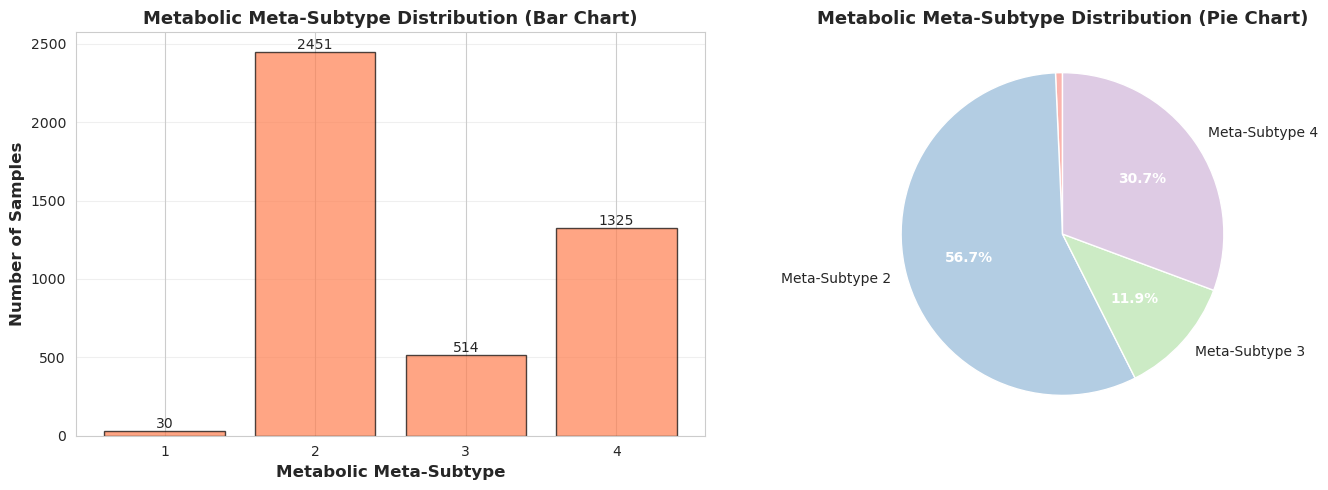


Meta-Subtype visualization completed!


In [12]:
# Visualize Meta-Subtype Distribution
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart
ax1 = axes[0]
bars = ax1.bar(meta_subtype_df['Meta_Subtype'].astype(str), meta_subtype_df['Count'], 
               color='coral', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Metabolic Meta-Subtype', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Metabolic Meta-Subtype Distribution (Bar Chart)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

# Plot 2: Pie chart
ax2 = axes[1]
colors = sns.color_palette('Pastel1', len(meta_subtype_df))

# Calculate percentages and create labels only for >= 5%
percentages = (meta_subtype_df['Count'] / len(predicted_meta_subtypes) * 100).values
labels = [f'Meta-Subtype {s}' if pct >= 5 else '' for s, pct in zip(meta_subtype_df['Meta_Subtype'], percentages)]

# Function to only show percentage if >= 5%
def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''

wedges, texts, autotexts = ax2.pie(meta_subtype_df['Count'], 
                                     labels=labels, 
                                     autopct=autopct_format,
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 10})
ax2.set_title('Metabolic Meta-Subtype Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

print("\nMeta-Subtype visualization completed!")

## 9. Create Results DataFrame

Combine predictions with sample metadata into a comprehensive results dataframe, including both subtype and meta-subtype predictions.

In [13]:
# Create results dataframe
results_df = pd.DataFrame({
    'sample_id': sample_ids,
    'predicted_subtype': predicted_subtypes,
    'predicted_meta_subtype': predicted_meta_subtypes
})

# Add prediction probabilities if available
if prediction_probs is not None:
    # Add probability for each class
    for i, class_label in enumerate(classifier.classes_):
        results_df[f'prob_subtype_{class_label}'] = prediction_probs[:, i]
    
    # Add max probability (confidence)
    results_df['prediction_confidence'] = np.max(prediction_probs, axis=1)

# Add basic metadata from adata if available
# You can add more metadata columns based on what's available in adata.obs
if 'age' in adata.obs.columns:
    results_df['age'] = adata.obs.loc[sample_ids, 'age'].values
if 'sex' in adata.obs.columns:
    results_df['sex'] = adata.obs.loc[sample_ids, 'sex'].values

print(f"Results dataframe created!")
print(f"Shape: {results_df.shape}")
print(f"\nColumn names:")
for col in results_df.columns:
    print(f"  - {col}")

print(f"\nFirst few rows:")
print(results_df.head(10))

# Display meta-subtype distribution in results
print(f"\nMeta-subtype distribution in results:")
for meta_subtype in sorted(results_df['predicted_meta_subtype'].unique()):
    count = (results_df['predicted_meta_subtype'] == meta_subtype).sum()
    percentage = (count / len(results_df) * 100)
    print(f"  Meta-subtype {meta_subtype}: {count} samples ({percentage:.2f}%)")

Results dataframe created!
Shape: (4320, 17)

Column names:
  - sample_id
  - predicted_subtype
  - predicted_meta_subtype
  - prob_subtype_0
  - prob_subtype_1
  - prob_subtype_2
  - prob_subtype_3
  - prob_subtype_4
  - prob_subtype_5
  - prob_subtype_6
  - prob_subtype_7
  - prob_subtype_8
  - prob_subtype_9
  - prob_subtype_10
  - prob_subtype_11
  - prob_subtype_12
  - prediction_confidence

First few rows:
   sample_id  predicted_subtype  predicted_meta_subtype  prob_subtype_0  \
0  1029146_0                  0                       2    9.995116e-01   
1  1033478_0                  1                       4    2.179988e-24   
2  1054955_0                  2                       2    5.173354e-23   
3  1058307_0                  3                       2    5.690019e-02   
4  1126004_0                  1                       4    6.093443e-22   
5  1149623_0                  1                       4    2.666725e-19   
6  1192030_0                  3                       2    

## Save Results

Save the prediction results for downstream analysis, including subtype distributions, meta-subtype distributions, and mappings.

In [14]:
# Create output directory
output_dir = './Demo_output'
os.makedirs(output_dir, exist_ok=True)

# Save results as CSV
results_csv_path = os.path.join(output_dir, 'metabolic_subtype_predictions.csv')
results_df.to_csv(results_csv_path, index=False)
print(f"Results saved to CSV: {results_csv_path}")

# Save subtype distribution
subtype_dist_path = os.path.join(output_dir, 'subtype_distribution.csv')
subtype_df.to_csv(subtype_dist_path, index=False)
print(f"Subtype distribution saved to: {subtype_dist_path}")

# Save meta-subtype distribution
meta_subtype_dist_path = os.path.join(output_dir, 'meta_subtype_distribution.csv')
meta_subtype_df.to_csv(meta_subtype_dist_path, index=False)
print(f"Meta-subtype distribution saved to: {meta_subtype_dist_path}")

# Save subtype to meta-subtype mapping
mapping_df = pd.DataFrame([
    {'Subtype': k, 'Meta_Subtype': v} 
    for k, v in sorted(subtype_to_meta.items())
])
mapping_path = os.path.join(output_dir, 'subtype_to_meta_mapping.csv')
mapping_df.to_csv(mapping_path, index=False)
print(f"Subtype-to-meta-subtype mapping saved to: {mapping_path}")

print(f"\nAll results saved successfully!")

Results saved to CSV: ./Demo_output/metabolic_subtype_predictions.csv
Subtype distribution saved to: ./Demo_output/subtype_distribution.csv
Meta-subtype distribution saved to: ./Demo_output/meta_subtype_distribution.csv
Subtype-to-meta-subtype mapping saved to: ./Demo_output/subtype_to_meta_mapping.csv

All results saved successfully!


## Summary and Next Steps

### Summary

This notebook demonstrated how to:
1. ✓ Load pre-extracted embeddings from the MetFoundation model
2. ✓ Load a trained metabolic subtype classifier
3. ✓ Predict metabolic subtypes for validation samples
4. ✓ Convert subtypes to meta-subtypes based on hierarchical grouping
5. ✓ Analyze and visualize both subtype and meta-subtype distributions
6. ✓ Create comprehensive results dataframes with both subtype levels
7. ✓ Save all results for downstream analysis

### Key Results

- **Total samples analyzed**: Check the output above
- **Number of metabolic subtypes**: Check the distribution table (Section 7)
- **Number of meta-subtypes**: 4 meta-subtypes defined by hierarchical grouping
- **Prediction confidence**: Available in results dataframe (if probabilistic classifier)
- **Top subtype**: Most common metabolic subtype identified
- **Top meta-subtype**: Most common meta-subtype identified

### Subtype Grouping

The meta-subtypes are defined as follows:
- **Meta-subtype 1**: Subtype 8
- **Meta-subtype 2**: Subtypes 0, 5, 2, 3
- **Meta-subtype 3**: Subtypes 6, 9, 12, 7, 10
- **Meta-subtype 4**: Subtypes 4, 1, 11

### Output Files

All results are saved in `./Demo_output/`:
- `metabolic_subtype_predictions.csv`: Full prediction results with metadata (includes both subtype and meta-subtype)
- `subtype_distribution.csv`: Summary of fine-grained subtype distribution
- `meta_subtype_distribution.csv`: Summary of meta-subtype distribution
- `subtype_to_meta_mapping.csv`: Mapping between subtypes and meta-subtypes

